In [1]:
import pandas as pd

# Load dataset
data = pd.read_csv("Churn_Modelling.csv")

data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [2]:
print(data.shape)
print(data.info())

(10000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None


In [3]:
data = data.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

In [4]:
# Convert Gender
data['Gender'] = data['Gender'].map({'Male': 0, 'Female': 1})

# One-hot encode Geography
data = pd.get_dummies(data, columns=['Geography'], drop_first=True)

In [5]:
X = data.drop('Exited', axis=1)
y = data['Exited']

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Logistic Regression
lr = LogisticRegression()
lr.fit(X_train, y_train)

# Random Forest
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

In [9]:
from sklearn.metrics import accuracy_score, classification_report

# Logistic
y_pred_lr = lr.predict(X_test)
print("🔹 Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

# Random Forest
y_pred_rf = rf.predict(X_test)
print("\n🔹 Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

🔹 Logistic Regression
Accuracy: 0.811
              precision    recall  f1-score   support

           0       0.83      0.96      0.89      1607
           1       0.55      0.20      0.29       393

    accuracy                           0.81      2000
   macro avg       0.69      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000


🔹 Random Forest
Accuracy: 0.87
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.77      0.48      0.59       393

    accuracy                           0.87      2000
   macro avg       0.83      0.72      0.76      2000
weighted avg       0.86      0.87      0.86      2000



In [12]:
def predict_churn(input_data):
    import pandas as pd

    # Convert to DataFrame with correct column names
    input_df = pd.DataFrame([input_data], columns=data.drop('Exited', axis=1).columns)

    # Scale
    input_scaled = scaler.transform(input_df)

    # Predict
    result = rf.predict(input_scaled)[0]

    return "❌ Customer Will Churn" if result == 1 else "✅ Customer Will Stay"

In [13]:
sample = X_test[0]  # use existing test sample
print(predict_churn(sample))

❌ Customer Will Churn


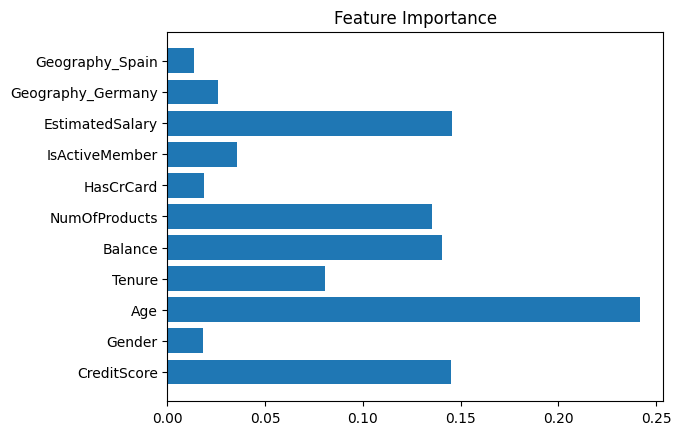

In [14]:
import matplotlib.pyplot as plt

importances = rf.feature_importances_
features = data.drop('Exited', axis=1).columns

plt.barh(features, importances)
plt.title("Feature Importance")
plt.show()